In [87]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.datasets import load_iris, make_classification, make_moons
from sklearn.svm import LinearSVC, SVC
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures, StandardScaler



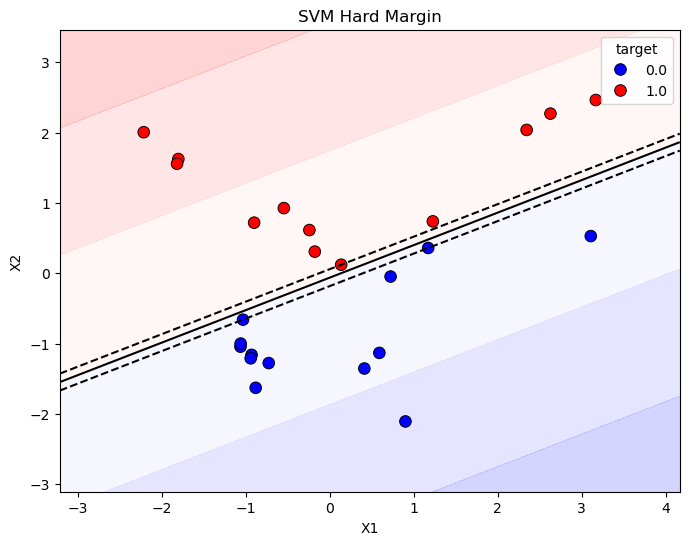

In [38]:
X, y = make_classification(
    n_classes=2, n_features=2, n_informative=2, n_redundant=0,
    n_samples=25, random_state=15,
)
data = pd.DataFrame(
    data=np.column_stack((X,y)), columns=['X1', 'X2', 'target'],
)
model = SVC(C=1e6, kernel='linear')
model.fit(X,y)

plt.figure(figsize=(8,6))
ax = plt.gca()

DecisionBoundaryDisplay.from_estimator(
    model, X,
    plot_method='contourf', 
    response_method='decision_function',
    cmap='bwr', 
    alpha=0.2,
    ax=ax
)

DecisionBoundaryDisplay.from_estimator(
    model, X,
    plot_method='contour',              
    response_method='decision_function',
    levels=[-1, 0, 1],                   
    linestyles=['--', '-', '--'],        
    colors='k',                          
    ax=ax
)
sns.scatterplot(
    data=data, x='X1', y='X2', hue='target', 
    palette=['blue', 'red'], s=70, edgecolor='k', ax=ax
)
plt.title('SVM Hard Margin')
plt.show()

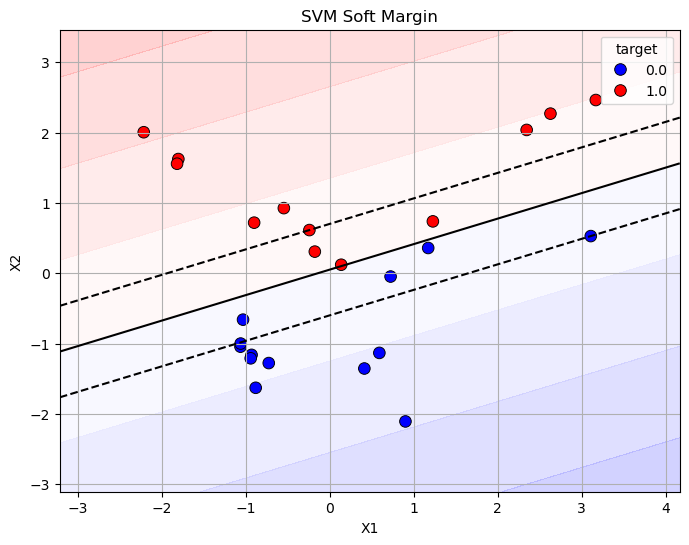

In [51]:
model = SVC(C=1, kernel='linear')
model.fit(X,y)

plt.figure(figsize=(8,6))
ax = plt.gca()

DecisionBoundaryDisplay.from_estimator(
    model, X,
    plot_method='contourf', 
    response_method='decision_function',
    cmap='bwr', 
    alpha=0.2,
    ax=ax
)

DecisionBoundaryDisplay.from_estimator(
    model, X,
    plot_method='contour',              
    response_method='decision_function',
    levels=[-1, 0, 1],                   
    linestyles=['--', '-', '--'],        
    colors='k',                          
    ax=ax
)
sns.scatterplot(
    data=data, x='X1', y='X2', hue='target', 
    palette=['blue', 'red'], s=70, edgecolor='k', ax=ax
)
plt.title('SVM Soft Margin')
plt.grid()
plt.show()

In [53]:
model.support_vectors_.shape

(8, 2)

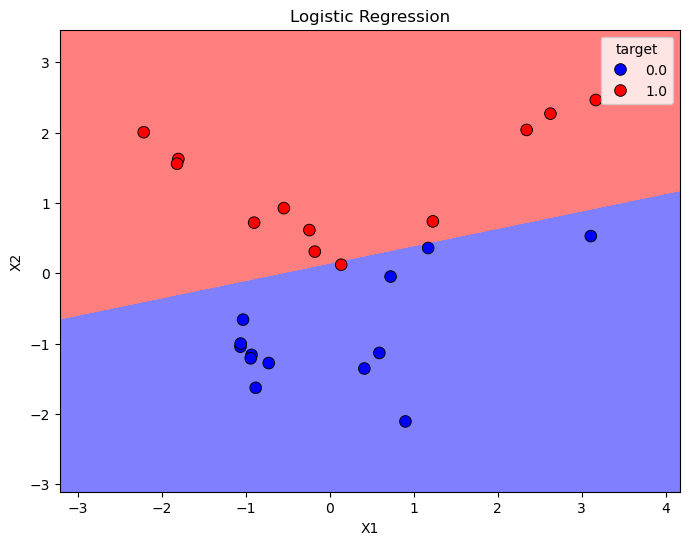

In [40]:
model = LogisticRegression()
model.fit(X,y)

plt.figure(figsize=(8,6))
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(
    model, X,
    plot_method='contourf', response_method='predict_proba',
    levels=1, cmap ='bwr', ax=ax
)
sns.scatterplot(
    data=data, x='X1', y='X2', hue='target', 
    palette=['blue', 'red'], s=70, edgecolor='k', ax=ax
)
plt.title('Logistic Regression')
plt.show()

Hinge loss is a convex loss function used primarily in training Support Vector Machines (SVMs) for maximum-margin classification, penalizing incorrect predictions and predictions that fall within the classification margin.$$L(w, b) = \max\left(0, 1 - y_i(w \cdot x_i + b)\right)$$Where $y_i \in \{-1, 1\}$ is the true class label, and $w \cdot x_i + b$ is the unthresholded model prediction (or raw margin score).

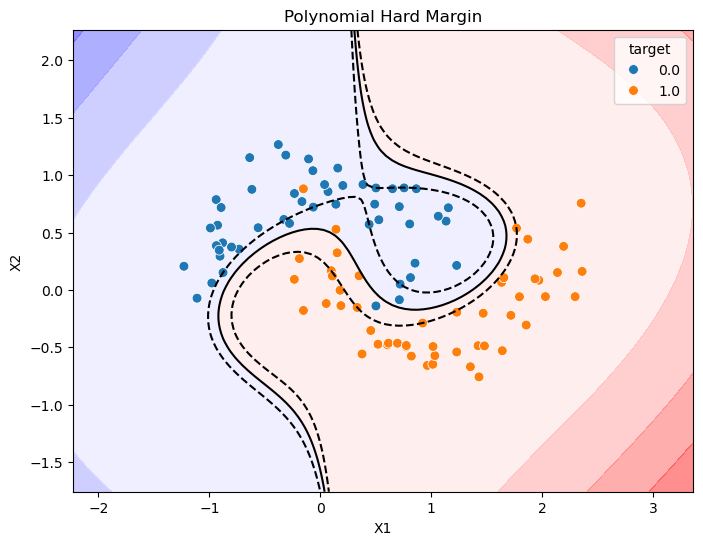

In [107]:
X, y = make_moons(n_samples=100, shuffle=True, noise=0.2, random_state=26)
data = pd.DataFrame(data=np.column_stack((X,y)), columns=['X1', 'X2', 'target'])
model = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearSVC(C=50, loss='hinge', max_iter=50000))
])
model.fit(X,y)

plt.figure(figsize=(8,6))
DecisionBoundaryDisplay.from_estimator(
    model, X, 
    response_method='decision_function', plot_method='contourf',
    cmap='bwr', ax= plt.gca(), alpha=0.5,
)
DecisionBoundaryDisplay.from_estimator(
    model, X,
    plot_method='contour', response_method='decision_function',
    levels=[-1, 0, 1], linestyles=['--', '-', '--'], colors='k',                          
    ax=plt.gca(),
)
plt.title('Polynomial Hard Margin')
sns.scatterplot(data=data, x='X1', y='X2', hue='target', s=50)
plt.show()